# Константы, импорты

In [492]:
import os

SEED = 1610

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import random
import numpy as np
import tensorflow as tf

random.seed(SEED)

from numpy.random import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, precision_recall_curve
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

TARGET = "stroke"

DATASET_PATH = "./healthcare-dataset-stroke-data.xls"

numeric_cols = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
numeric_cols_without_id = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Загрузка данных

In [493]:
df = pd.read_csv(DATASET_PATH)
print('Размер:', df.shape)
print(df[TARGET].value_counts())
df.head()

Размер: (5110, 12)
stroke
0    4861
1     249
Name: count, dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Анализ сырых данных

Анализ данных до преобразования категориальных признаков

## Базовый анализ, взгляд на данные

In [494]:
print('=== Типы данных, количество пропусков ===')
df.info()

=== Типы данных, количество пропусков ===
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [495]:
print('=== Статистика по числовым и категориальным признакам ===')
df.describe(include='all')

=== Статистика по числовым и категориальным признакам ===


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [496]:
print ('=== Количество уникальных значений по колонкам (категориальные колонки) ===')
for col in cat_cols:
    print(f'{col}: {df[col].nunique()}')

=== Количество уникальных значений по колонкам (категориальные колонки) ===
gender: 3
ever_married: 2
work_type: 5
Residence_type: 2
smoking_status: 4


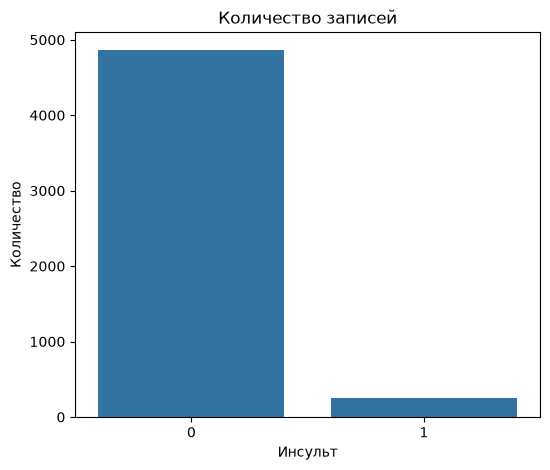

In [497]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x=TARGET)
plt.xlabel('Инсульт')
plt.ylabel('Количество')
plt.title('Количество записей')
plt.show()

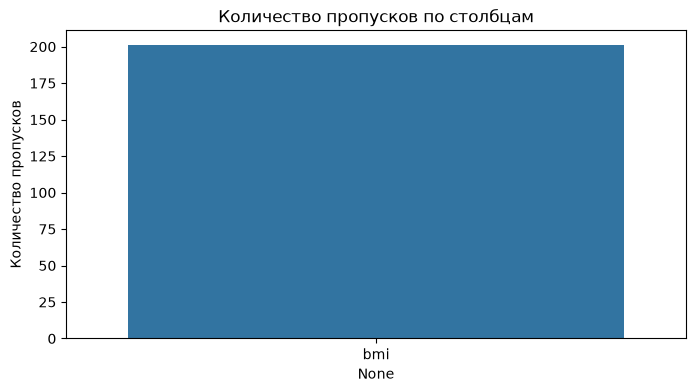

In [498]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title('Количество пропусков по столбцам')
plt.ylabel('Количество пропусков')
plt.show()

## Анализ числовых признаков

### Анализ распределения (ящики с усами)

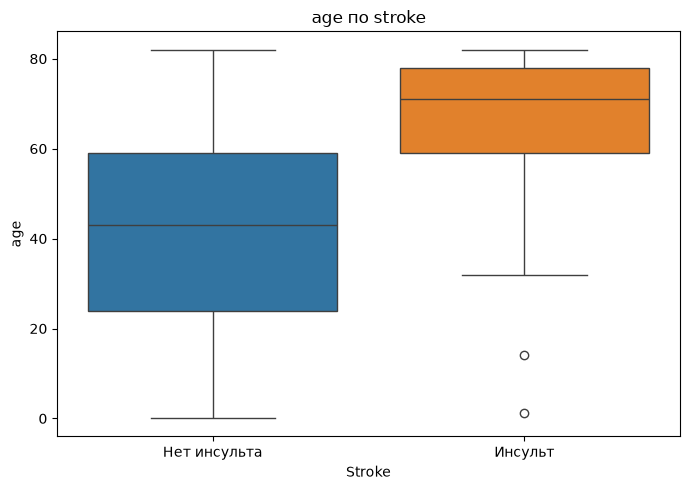


Распределение: age

Stroke = 0 (Нет инсульта)
  Количество:       4861
  Min:              0.08
  Q1 (25%):         24.00
  Median (50%):     43.00
  Q3 (75%):         59.00
  Max:              82.00
  IQR:              35.00
  Нижний ус:        0.08
  Верхний ус:       82.00
  Выбросов:         0

Stroke = 1 (Инсульт)
  Количество:       249
  Min:              1.32
  Q1 (25%):         59.00
  Median (50%):     71.00
  Q3 (75%):         78.00
  Max:              82.00
  IQR:              19.00
  Нижний ус:        32.00
  Верхний ус:       82.00
  Выбросов:         2


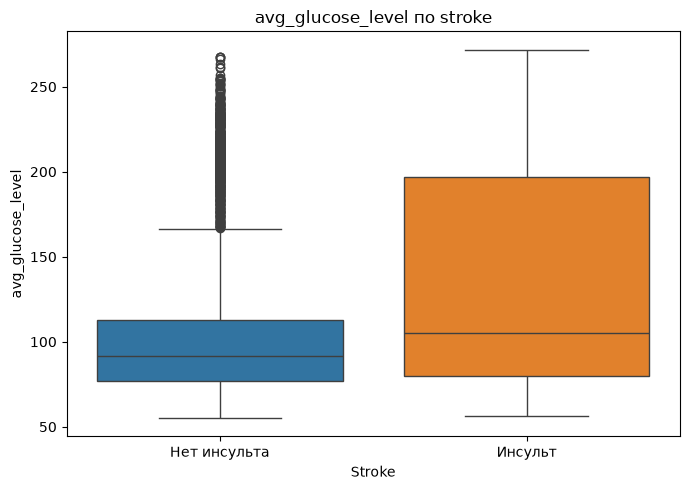


Распределение: avg_glucose_level

Stroke = 0 (Нет инсульта)
  Количество:       4861
  Min:              55.12
  Q1 (25%):         77.12
  Median (50%):     91.47
  Q3 (75%):         112.83
  Max:              267.76
  IQR:              35.71
  Нижний ус:        55.12
  Верхний ус:       166.38
  Выбросов:         551

Stroke = 1 (Инсульт)
  Количество:       249
  Min:              56.11
  Q1 (25%):         79.79
  Median (50%):     105.22
  Q3 (75%):         196.71
  Max:              271.74
  IQR:              116.92
  Нижний ус:        56.11
  Верхний ус:       271.74
  Выбросов:         0


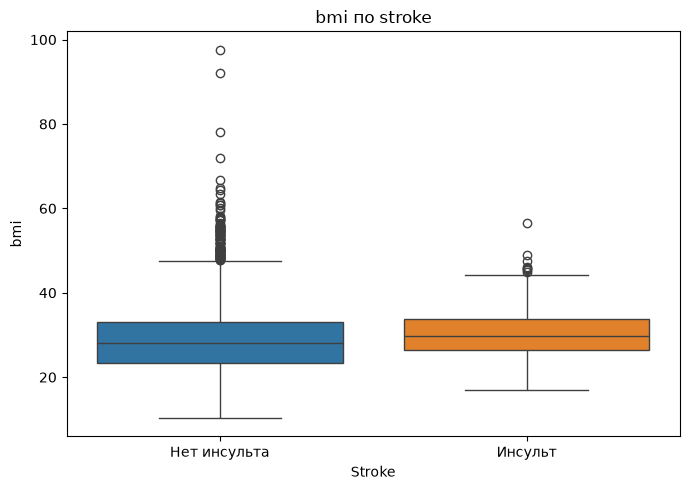


Распределение: bmi

Stroke = 0 (Нет инсульта)
  Количество:       4700
  Min:              10.30
  Q1 (25%):         23.40
  Median (50%):     28.00
  Q3 (75%):         33.10
  Max:              97.60
  IQR:              9.70
  Нижний ус:        10.30
  Верхний ус:       47.60
  Выбросов:         105

Stroke = 1 (Инсульт)
  Количество:       209
  Min:              16.90
  Q1 (25%):         26.40
  Median (50%):     29.70
  Q3 (75%):         33.70
  Max:              56.60
  IQR:              7.30
  Нижний ус:        16.90
  Верхний ус:       44.20
  Выбросов:         8


In [499]:
def plot_boxplots_with_statistics(df, columns, target='stroke'):
    for col in columns:
        plt.figure(figsize=(7, 5))

        sns.boxplot(
            data=df,
            x=target,
            y=col,
            hue=target,
            legend=False
        )

        plt.title(f'{col} по {target}')
        plt.xlabel('Stroke')
        plt.ylabel(col)
        plt.xticks(
            [0, 1],
            ['Нет инсульта', 'Инсульт']
        )

        plt.tight_layout()
        plt.show()

        print(f'\n{"=" * 50}')
        print(f'Распределение: {col}')
        print(f'{"=" * 50}')

        for stroke_value in sorted(df[target].dropna().unique()):

            values = df.loc[
                df[target] == stroke_value,
                col
            ].dropna()

            q1 = values.quantile(0.25)
            median = values.quantile(0.50)
            q3 = values.quantile(0.75)

            iqr = q3 - q1

            lower_limit = q1 - 1.5 * iqr
            upper_limit = q3 + 1.5 * iqr

            lower_whisker = values[
                values >= lower_limit
            ].min()

            upper_whisker = values[
                values <= upper_limit
            ].max()

            outliers = values[
                (values < lower_limit) |
                (values > upper_limit)
            ]

            print(
                f'\nStroke = {stroke_value} '
                f'({"Нет инсульта" if stroke_value == 0 else "Инсульт"})'
            )

            print(f'  Количество:       {len(values)}')
            print(f'  Min:              {values.min():.2f}')
            print(f'  Q1 (25%):         {q1:.2f}')
            print(f'  Median (50%):     {median:.2f}')
            print(f'  Q3 (75%):         {q3:.2f}')
            print(f'  Max:              {values.max():.2f}')
            print(f'  IQR:              {iqr:.2f}')
            print(f'  Нижний ус:        {lower_whisker:.2f}')
            print(f'  Верхний ус:       {upper_whisker:.2f}')
            print(f'  Выбросов:         {len(outliers)}')
    
plot_boxplots_with_statistics(df, ['age', 'avg_glucose_level', 'bmi'])

### Анализ бинарных признаков

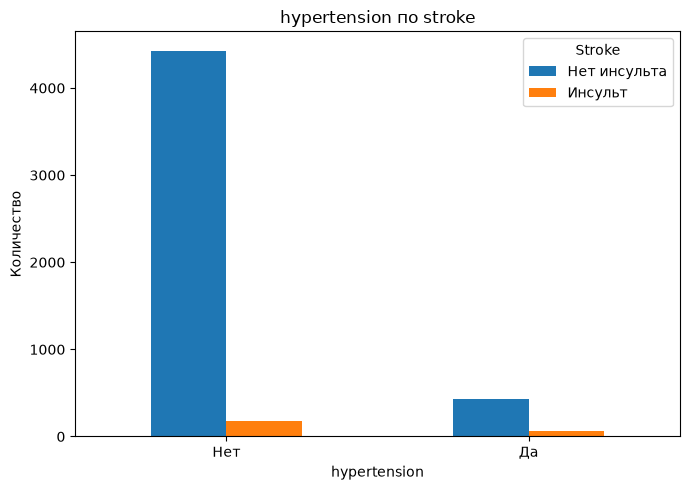


hypertension

hypertension = 0
  Всего:              4612
  Без инсульта:       4429
  С инсультом:        183
  Доля инсульта:      3.97%

hypertension = 1
  Всего:              498
  Без инсульта:       432
  С инсультом:        66
  Доля инсульта:      13.25%


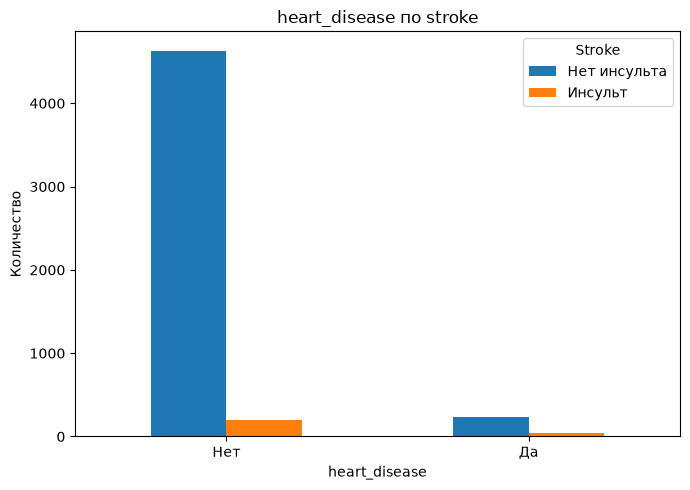


heart_disease

heart_disease = 0
  Всего:              4834
  Без инсульта:       4632
  С инсультом:        202
  Доля инсульта:      4.18%

heart_disease = 1
  Всего:              276
  Без инсульта:       229
  С инсультом:        47
  Доля инсульта:      17.03%


In [500]:
def plot_binary_by_stroke(df, columns, target='stroke'):
    for col in columns:
        counts = (
            df.groupby([col, target])
            .size()
            .unstack(fill_value=0)
        )

        # График
        counts.plot(
            kind='bar',
            figsize=(7, 5)
        )

        plt.title(f'{col} по {target}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(
            [0, 1],
            ['Нет', 'Да'],
            rotation=0
        )
        plt.legend(
            ['Нет инсульта', 'Инсульт'],
            title='Stroke'
        )
        plt.tight_layout()
        plt.show()

        print(f'\n{"=" * 50}')
        print(f'{col}')
        print(f'{"=" * 50}')

        for value in sorted(df[col].dropna().unique()):
            subset = df[df[col] == value]

            total = len(subset)
            strokes = subset[target].sum()
            stroke_rate = strokes / total * 100

            print(f'\n{col} = {value}')
            print(f'  Всего:              {total}')
            print(f'  Без инсульта:       {(subset[target] == 0).sum()}')
            print(f'  С инсультом:        {strokes}')
            print(f'  Доля инсульта:      {stroke_rate:.2f}%')
            
plot_binary_by_stroke(
    df,
    ['hypertension', 'heart_disease']
)

### Анализ распределения (Skewness)

In [501]:
from scipy.stats import skew
print(df[numeric_cols].apply(skew))

id                  -0.019907
age                 -0.137019
hypertension         2.714595
heart_disease        3.946085
avg_glucose_level    1.571822
bmi                       NaN
dtype: float64


### Анализ выбросов

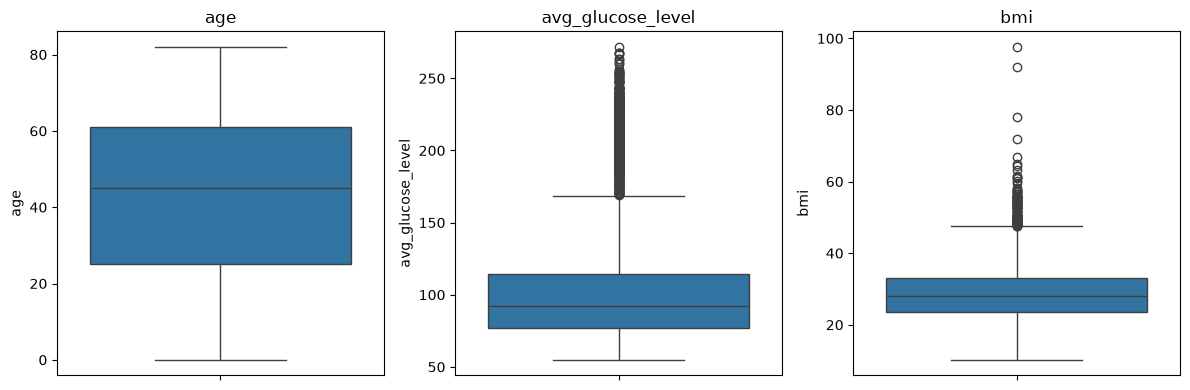

In [502]:
plt.figure(figsize=(12,4))
num_cols = ['age', 'avg_glucose_level', 'bmi']
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Анализ категориальных признаков

### Столбчатые диаграммы для категориальных признаков

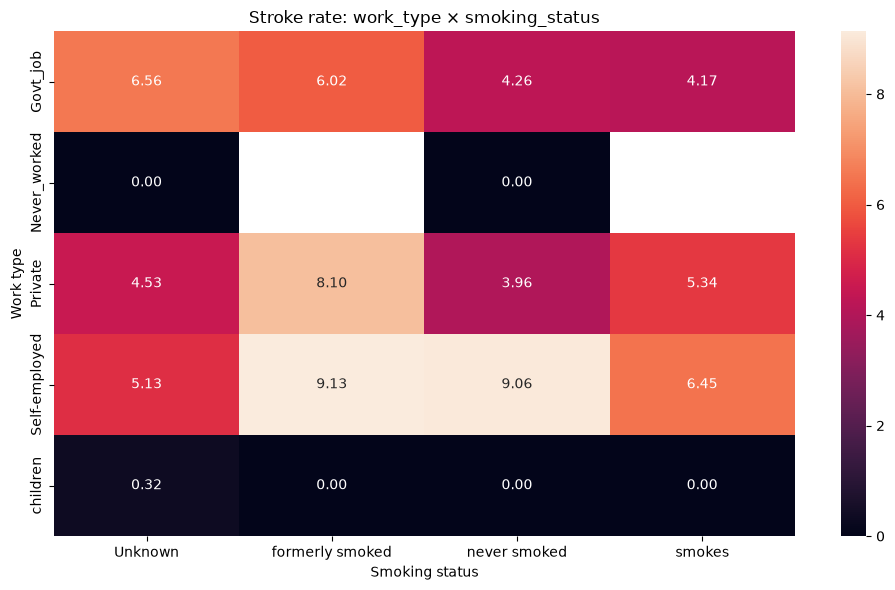

In [503]:
table = pd.pivot_table(
    df,
    values='stroke',
    index='work_type',
    columns='smoking_status',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    table,
    annot=True,
    fmt='.2f'
)

plt.title('Stroke rate: work_type × smoking_status')
plt.xlabel('Smoking status')
plt.ylabel('Work type')
plt.tight_layout()
plt.show()

# Подготовка данных. Преобразование категориальных признаков

In [504]:
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].replace([np.inf, -np.inf], np.nan)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['smoking_status'] = df['smoking_status'].fillna(df['smoking_status'].mode()[0])

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Анализ данных после преобразования

## HeatMap параметров

Топ-10 признаков, наиболее коррелирующих с stroke:
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.036110
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
id                   0.006388
Name: stroke, dtype: float64


C:\Users\Aleksei\AppData\Local\Temp\ipykernel_20012\4125207938.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include=['object']).columns:
C:\Users\Aleksei\AppData\Local\Temp\ipykernel_20012\4125207938.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


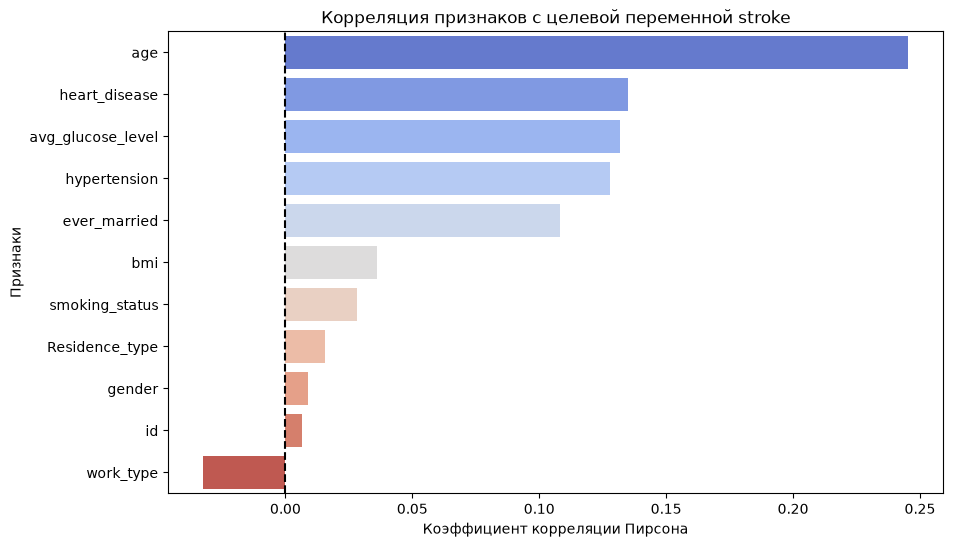

In [505]:
from sklearn.preprocessing import LabelEncoder

df_encoded = X.copy()
df_encoded[TARGET] = y

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

corr = df_encoded.corr()

corr_with_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)

print(f"Топ-10 признаков, наиболее коррелирующих с {TARGET}:")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Корреляция признаков с целевой переменной ' + TARGET)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Признаки')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Feature Engineering

На предыдущем шаге стали известны параметры, которые более всего влияют на сигнал Stroke. На основе этой информации можно вывести новые признаки

In [506]:
def create_features(df):
    df = df.copy()
    
    df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 65, 75, 120], 
                             labels=[0, 1, 2, 3, 4])
    df['is_elderly'] = (df['age'] >= 65).astype(int)
    df['age_squared'] = df['age'] ** 2
    
    df['age_hypertension'] = df['age'] * df['hypertension']
    df['age_heart_disease'] = df['age'] * df['heart_disease']
    df['age_glucose'] = df['age'] * df['avg_glucose_level']
    df['age_bmi'] = df['age'] * df['bmi']
    
    df['high_glucose'] = (df['avg_glucose_level'] > 140).astype(int)
    df['very_high_glucose'] = (df['avg_glucose_level'] > 200).astype(int)
    df['glucose_group'] = pd.cut(df['avg_glucose_level'], 
                                 bins=[0, 100, 140, 200, 300], 
                                 labels=[0, 1, 2, 3])
    
    df['bmi_group'] = pd.cut(df['bmi'], 
                             bins=[0, 18.5, 25, 30, 35, 100], 
                             labels=[0, 1, 2, 3, 4])
    df['is_obese'] = (df['bmi'] >= 30).astype(int)
    df['is_overweight'] = (df['bmi'] >= 25).astype(int)
    
    df['risk_score'] = (df['hypertension'] + 
                        df['heart_disease'] + 
                        df['is_obese'] + 
                        df['high_glucose'] + 
                        df['is_elderly'])
    
    df['cardio_risk'] = df['hypertension'] + df['heart_disease']
        
    return df

# Разделение данных на тренировочную и тестовую выборки

In [507]:
X_enhanced = create_features(X)
X_enhanced = X_enhanced.drop(['id'], axis=1)

keras_cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type',
                  'smoking_status', 'age_group', 'glucose_group', 'bmi_group']
keras_num_cols = [c for c in X_enhanced.columns if c not in keras_cat_cols]

X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=SEED, stratify=y
)

X_tr = X_tr_raw.copy()
X_val = X_val_raw.copy()
cat_encoders = {}

for col in keras_cat_cols:
    le = LabelEncoder()
    X_tr[col] = le.fit_transform(X_tr[col].astype(str))
    classes_set = set(le.classes_)
    X_val[col] = X_val[col].astype(str).map(
        lambda s: le.transform([s])[0] if s in classes_set else 0
    )
    cat_encoders[col] = le
    
for col in keras_num_cols:
    X_tr[col] = X_tr[col].astype('float32')
    X_val[col] = X_val[col].astype('float32')
    
smote = SMOTE(sampling_strategy=0.3, random_state=SEED)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
X_tr_res = pd.DataFrame(X_tr_res, columns=X_tr.columns)
y_tr_res = pd.Series(y_tr_res, name='stroke')

cat_cardinalities = {col: int(X_tr_res[col].max()) + 1 for col in keras_cat_cols}
print("Cardinalities:", cat_cardinalities)
print("Train after SMOTE:", y_tr_res.value_counts().to_dict())

def build_wide_and_deep(num_cols, cat_cardinalities):
    num_input = layers.Input(shape=(len(num_cols),), name='numeric')
    cat_inputs, cat_embeds, cat_onehots = {}, [], []

    for col, card in cat_cardinalities.items():
        inp = layers.Input(shape=(1,), name=col, dtype='int32')
        cat_inputs[col] = inp
        emb_dim = min(50, (card + 1) // 2)
        emb = layers.Embedding(input_dim=card, output_dim=emb_dim)(inp)
        emb = layers.Flatten()(emb)
        cat_embeds.append(emb)
        oh = layers.CategoryEncoding(num_tokens=card, output_mode='one_hot')(inp)
        cat_onehots.append(oh)

    wide_in = layers.Concatenate()(cat_onehots + [num_input])
    wide_out = layers.Dense(1, activation=None, name='wide_out')(wide_in)

    deep_in = layers.Concatenate()(cat_embeds + [num_input])
    x = layers.Dense(128, activation='relu')(deep_in)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    deep_out = layers.Dense(1, activation=None, name='deep_out')(x)

    combined = layers.Add()([wide_out, deep_out])
    output = layers.Activation('sigmoid', name='output')(combined)

    return Model(inputs=[num_input] + list(cat_inputs.values()), outputs=output)

model = build_wide_and_deep(keras_num_cols, cat_cardinalities)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)
model.summary()

def make_inputs(df, num_cols, cat_cols):
    num_data = df[num_cols].values.astype('float32')
    cat_data = [df[c].values.reshape(-1, 1).astype('int32') for c in cat_cols]
    return [num_data] + cat_data

train_inputs = make_inputs(X_tr_res, keras_num_cols, keras_cat_cols)
val_inputs   = make_inputs(X_val,    keras_num_cols, keras_cat_cols)

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr_res.values)
class_weight_dict = {0: cw[0], 1: cw[1]}
print("Class weights:", class_weight_dict)

Cardinalities: {'gender': 3, 'ever_married': 2, 'work_type': 5, 'Residence_type': 2, 'smoking_status': 4, 'age_group': 5, 'glucose_group': 4, 'bmi_group': 5}
Train after SMOTE: {0: 3889, 1: 1166}


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gender (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ever_married        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ work_type           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residence_type      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ smoking_status      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glucose_group       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bmi_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_184       │ (None, 1, 2)      │          6 │ gender[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_185       │ (None, 1, 1)      │          2 │ ever_married[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_186       │ (None, 1, 3)      │         15 │ work_type[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_187       │ (None, 1, 1)      │          2 │ Residence_type[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_188       │ (None, 1, 2)      │          8 │ smoking_status[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_189       │ (None, 1, 3)      │         15 │ age_group[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_190       │ (None, 1, 2)      │          8 │ glucose_group[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_191       │ (None, 1, 3)      │         15 │ bmi_group[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 15,736 (61.47 KB)

 Trainable params: 15,352 (59.97 KB)

 Non-trainable params: 384 (1.50 KB)

Class weights: {0: np.float64(0.6499100025713551), 1: np.float64(2.1676672384219553)}


# Обучение модели

In [508]:
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
]

history = model.fit(
    train_inputs, y_tr_res.values,
    validation_data=(val_inputs, y_val.values),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

y_pred_proba = model.predict(val_inputs).ravel()

precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)
target_recall = 0.76

valid_indices = np.where(recall[:-1] >= target_recall)[0]

if len(valid_indices) > 0:
    # Среди подходящих threshold выбираем тот,
    # который даёт максимальный precision
    best_idx = valid_indices[
        np.argmax(precision[:-1][valid_indices])
    ]

    best_threshold = thresholds[best_idx]
else:
    # Если модель вообще не достигает recall 0.75
    best_idx = np.argmax(recall[:-1])
    best_threshold = thresholds[best_idx]

print(
    f"Threshold: {best_threshold:.3f} | "
    f"Precision: {precision[best_idx]:.3f} | "
    f"Recall: {recall[best_idx]:.3f} | "
    f"F1: {2 * precision[best_idx] * recall[best_idx] / (precision[best_idx] + recall[best_idx] + 1e-8):.3f}"
)

y_pred = (y_pred_proba >= best_threshold).astype(int)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2609 - auc: 0.5225 - loss: 296.6336 - precision: 0.2378 - recall: 0.9991 - val_accuracy: 0.1497 - val_auc: 0.5612 - val_loss: 242.8284 - val_precision: 0.0544 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5931 - auc: 0.6815 - loss: 31.2406 - precision: 0.3398 - recall: 0.8105 - val_accuracy: 0.8278 - val_auc: 0.7742 - val_loss: 3.7546 - val_precision: 0.1786 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7102 - auc: 0.7662 - loss: 2.6149 - precision: 0.4242 - recall: 0.7170 - val_accuracy: 0.8924 - val_auc: 0.6503 - val_loss: 1.2423 - val_precision: 0.1512 - val_recall: 0.2600 - learning_rate: 0.0010
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7227 - auc: 0.7756 - loss: 1.7746 - precision: 0.4377 - recall: 0.7110 - val_accuracy: 0.9325 - val_auc: 0.5431 - val_loss: 0.4467 - va

# Оценка качества

In [509]:
def print_metrics_explained(y_true, y_pred, target_names):
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    acc = report['accuracy']
    
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}% правильных ответов)")
    
    for name in target_names:
        m = report[name]
        print(f"\nКласс '{name}':")
        print(f"  precision = {m['precision']:.2f}  ({m['precision']*100:.0f}% предсказанных верны)")
        print(f"  recall    = {m['recall']:.2f}    ({m['recall']*100:.0f}% реальных найдены)")
        print(f"  f1-score  = {m['f1-score']:.2f}")
    
    macro = report['macro avg']
    weighted = report['weighted avg']
    print("\nСредние:")
    print(f"  macro avg    precision={macro['precision']:.2f}, recall={macro['recall']:.2f}, f1={macro['f1-score']:.2f}")
    print(f"  weighted avg precision={weighted['precision']:.2f}, recall={weighted['recall']:.2f}, f1={weighted['f1-score']:.2f}")

# График "Предсказание VS Реальность"

In [510]:
def plot_class_metrics(y_true, y_pred, target_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True
    )

    metrics = ['precision', 'recall', 'f1-score']

    values_0 = [
        report[target_names[0]]['precision'],
        report[target_names[0]]['recall'],
        report[target_names[0]]['f1-score']
    ]

    values_1 = [
        report[target_names[1]]['precision'],
        report[target_names[1]]['recall'],
        report[target_names[1]]['f1-score']
    ]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(8, 5))

    plt.bar(x - width/2, values_0, width, label=target_names[0])
    plt.bar(x + width/2, values_1, width, label=target_names[1])

    plt.xticks(x, metrics)
    plt.ylabel('Значение')
    plt.ylim(0, 1)
    plt.title('Метрики классификации по классам')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
def plot_real_vs_predicted(y_true, y_pred):
    real_counts = np.bincount(y_true)
    pred_counts = np.bincount(y_pred)

    x = np.arange(2)
    width = 0.35

    plt.figure(figsize=(7, 5))

    plt.bar(
        x - width/2,
        real_counts,
        width,
        label='Реальные'
    )

    plt.bar(
        x + width/2,
        pred_counts,
        width,
        label='Предсказанные'
    )

    plt.xticks(
        x,
        ['Нет инсульта', 'Инсульт']
    )

    plt.ylabel('Количество')
    plt.title('Реальное и предсказанное распределение классов')
    plt.legend()

    plt.tight_layout()
    plt.show()


Classification report:
              precision    recall  f1-score   support

Нет инсульта       0.98      0.81      0.89       972
     Инсульт       0.17      0.76      0.28        50

    accuracy                           0.81      1022
   macro avg       0.58      0.78      0.58      1022
weighted avg       0.95      0.81      0.86      1022

Accuracy: 0.8072  (80.72% правильных ответов)

Класс 'Нет инсульта':
  precision = 0.98  (98% предсказанных верны)
  recall    = 0.81    (81% реальных найдены)
  f1-score  = 0.89

Класс 'Инсульт':
  precision = 0.17  (17% предсказанных верны)
  recall    = 0.76    (76% реальных найдены)
  f1-score  = 0.28

Средние:
  macro avg    precision=0.58, recall=0.78, f1=0.58
  weighted avg precision=0.95, recall=0.81, f1=0.86


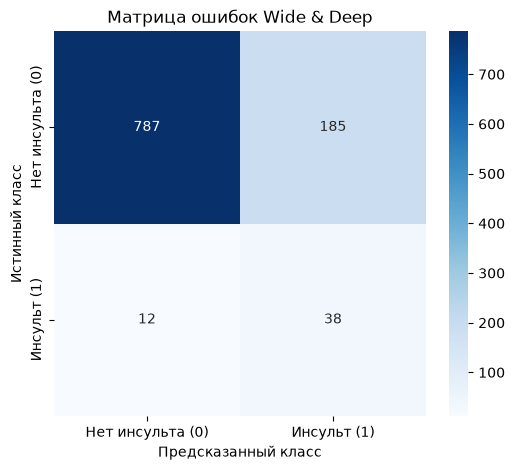

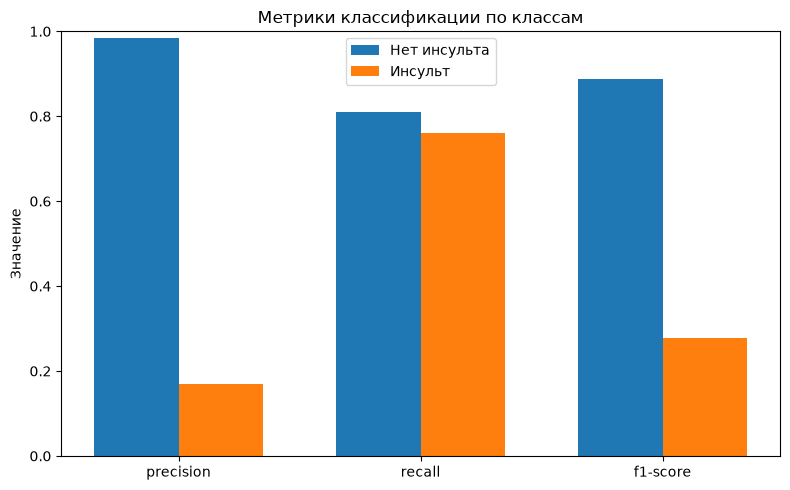

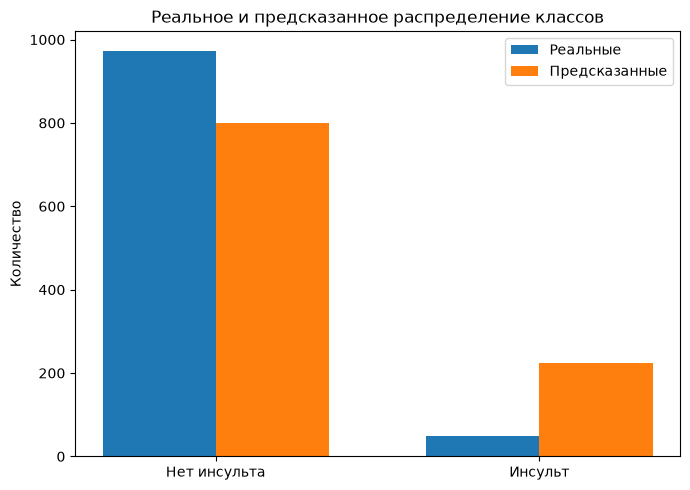

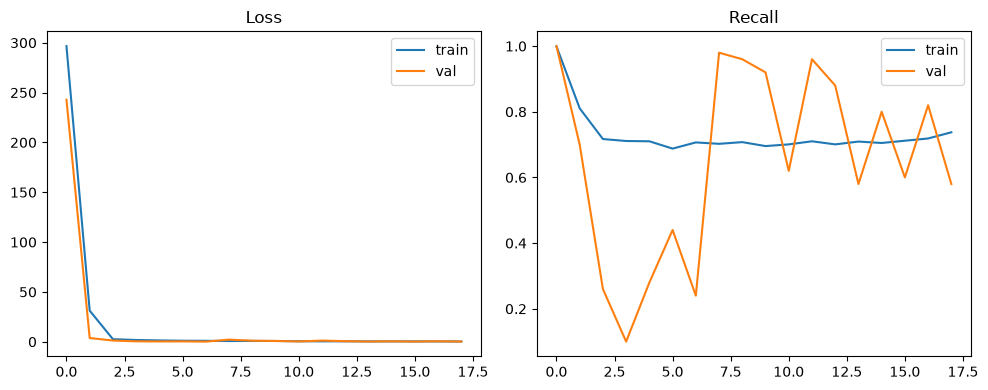

In [511]:
print("\nClassification report:")
print(classification_report(y_val, y_pred,
                            target_names=['Нет инсульта', 'Инсульт'],
                            zero_division=0))

print_metrics_explained(y_val, y_pred, ['Нет инсульта', 'Инсульт'])

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет инсульта (0)', 'Инсульт (1)'],
            yticklabels=['Нет инсульта (0)', 'Инсульт (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок Wide & Deep')
plt.show()

plot_class_metrics(y_val, y_pred, ['Нет инсульта', 'Инсульт'])
plot_real_vs_predicted(y_val, y_pred)

# График обучениея
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['recall'], label='train')
plt.plot(history.history['val_recall'], label='val')
plt.title('Recall'); plt.legend()
plt.tight_layout(); plt.show()